This notebook implements a few-shot classification pipeline using GPT-4.1 to label medication-related questions as either "General" (no immediate risk) or "Critical" (potentially dangerous interaction).

In outline, it:
1. **Loads and Prepares Data:**
Reads a set of held-out or test questions (with known "General"/ "Critical" labels) into memory.
Optionally shuffles or formats them for batch processing.

2. **Builds a Retrieval Component:**
 Queries a FAISS index to pull the top-k "Relevant context" passages for each test question. Aggregates those retrieved snippets so GPT-4.1 can consult them when making its decision.

3. **Constructs the GPT-4.1 Prompt:**
Defines a fixed instruction block that tells the model to act as a medical classification assistant and respond only with exactly "General" or "Critical".
Includes several hard-coded examples (questions plus their correct labels) to illustrate the expected input/output format. Inserts a small few-shot set of additional question-label pairs. Appends the retrieved context passages underneath, labeled "Relevant context (top-k passages)".
Appends the actual test question at the bottom and leaves a blank space for GPT-4.1's one-word answer.

4. **Calls the GPT-4.1 API:**
Sends each composed prompt to OpenAI's GPT-4.1 endpoint.
Receives a one-word reply ("General" or "Critical") and parses it into a Python variable.

5. **Aggregates and Evaluates Predictions:**
Compares GPT-4.1's returned labels against the ground-truth annotations.
Computes accuracy, precision, recall, and F1 for both classes.
Prints a summary report.

In short, this code demonstrates how to combine simple retrieval ("top-k context") with a structured, few-shot prompt for GPT-4.1, then batch-classify medical QA pairs and evaluate model performance.

In [ ]:
# Install required libraries
!pip install --quiet transformers datasets faiss-cpu accelerate

import os
import torch
import pandas as pd
from datasets import Dataset
from transformers import (
    RagTokenizer,
    RagRetriever,
    DPRContextEncoder,
    DPRContextEncoderTokenizer,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
# Imports for DPR + FAISS
import torch
import faiss
from transformers import (
    DPRContextEncoder,
    DPRContextEncoderTokenizer,
    DPRQuestionEncoder,
    DPRQuestionEncoderTokenizer
)

In [ ]:
!pip install azure-cli

## RAG Retrieval:
The stage where the "knowledge" from which RAG will draw segments is generated. It is critical to do this before computing embeddings.

In [ ]:
# Load & prepare the knowledge corpus:

import pandas as pd

# Load DDI interactions and build a text field
df1 = pd.read_csv("/content/DDI_data (3).csv")
df1 = df1[["drug1_name", "drug2_name", "interaction_type"]].dropna()
df1["source"] = "DDI"
df1["text"] = (
    df1["drug1_name"]
    + " may interact with "
    + df1["drug2_name"]
    + ": "
    + df1["interaction_type"]
)
df1.rename(
    columns={
        "drug1_name": "drug1",
        "drug2_name": "drug2",
        "interaction_type": "interaction",
    },
    inplace=True,
)

# Load EML medical uses and build a text field
df3 = pd.read_excel("/content/EML export (2).xlsx")
df3.columns = df3.columns.str.strip()
df3 = df3[["Medicine name", "Indication"]].dropna()
df3["source"] = "EML"
df3["text"] = df3["Medicine name"] + " is used for: " + df3["Indication"]
df3.rename(
    columns={"Medicine name": "medicine_name", "Indication": "indication"},
    inplace=True,
)

# Combine both sources into one DataFrame and drop duplicate sentences
knowledge_df = pd.concat([df1, df3], ignore_index=True)
knowledge_df.drop_duplicates(subset=["text"], inplace=True)

# Find drug names that appear in both sources
ddi_names = df1["drug1"].str.lower().unique()
eml_names = df3["medicine_name"].str.lower().unique()
common_names = set(ddi_names).intersection(eml_names)

# Filter only the overlapping entries to inspect them
overlapping_texts = knowledge_df[
    (
        (knowledge_df["source"] == "DDI")
        & knowledge_df["drug1"].str.lower().isin(common_names)
    )
    | (
        (knowledge_df["source"] == "EML")
        & knowledge_df["medicine_name"].str.lower().isin(common_names)
    )
]

print("Number of overlapping entries in corpus:", len(overlapping_texts))
display(overlapping_texts)

# Export the full corpus
knowledge_df.to_excel("knowledge_corpus.xlsx", index=False)

# Export only the overlapping entries
overlapping_texts.to_excel("overlapping_entries.xlsx", index=False)

Number of overlapping entries in corpus: 71983


,drug1,drug2,interaction,source,text,medicine_name,indication
225,Goserelin,Dofetilide,QTc-prolonging activities,DDI,Goserelin may interact with Dofetilide: QTc-pr...,NaN,NaN
226,Goserelin,Citalopram,QTc-prolonging activities,DDI,Goserelin may interact with Citalopram: QTc-pr...,NaN,NaN
227,Goserelin,Ziprasidone,QTc-prolonging activities,DDI,Goserelin may interact with Ziprasidone: QTc-p...,NaN,NaN
228,Goserelin,Anagrelide,QTc-prolonging activities,DDI,Goserelin may interact with Anagrelide: QTc-pr...,NaN,NaN
229,Goserelin,Disopyramide,QTc-prolonging activities,DDI,Goserelin may interact with Disopyramide: QTc-...,NaN,NaN
...,...,...,...,...,...,...,...
224261,NaN,NaN,NaN,EML,warfarin is used for: Atrial fibrillation,warfarin,Atrial fibrillation
224264,NaN,NaN,NaN,EML,xylometazoline is used for: Nasal congestion,xylometazoline,Nasal congestion
224268,NaN,NaN,NaN,EML,zidovudine is used for: Human immunodeficiency...,zidovudine,Human immunodeficiency virus disease without m...
224270,NaN,NaN,NaN,EML,zoledronic acid is used for: Malignant neoplas...,zoledronic acid,Malignant neoplasm metastasis in bone or bone ...


## Prepare and index RAG knowledge corpus:
Converts the texts to a HuggingFace dataset and adds an embeddings field. Must happen after saving the Excel, but before building the index.

In [ ]:
import torch
from datasets import Dataset
from transformers import (
    DPRContextEncoder,
    DPRContextEncoderTokenizer,
    RagTokenizer,
    RagRetriever
)
import pandas as pd
import faiss
import numpy as np

# Load corpus and build HF Dataset with title/text
knowledge_df = pd.read_excel("/content/knowledge_corpus.xlsx")
passages = knowledge_df["text"].tolist()
passages_ds = Dataset.from_dict({
    "title": [f"doc_{i}" for i in range(len(passages))],
    "text":  passages
})

# Compute DPR embeddings for each passage
device = "cuda" if torch.cuda.is_available() else "cpu"
ctx_tok = DPRContextEncoderTokenizer.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")
ctx_enc = DPRContextEncoder.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base").to(device)

def embed_batch(batch):
    toks = ctx_tok(batch["text"], truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        out = ctx_enc(**toks)
    return {"embeddings": out.pooler_output.cpu().numpy()}

passages_ds = passages_ds.map(
    embed_batch,
    batched=True,
    batch_size=32,
    load_from_cache_file=False
)

#Save HF Dataset to disk
passages_ds.save_to_disk("hf_knowledge_dataset")

# Build & write the Faiss index
embs = np.vstack(passages_ds["embeddings"]).astype("float32")  # ← ודאי float32
faiss.normalize_L2(embs)
d = embs.shape[1]
index = faiss.IndexFlatIP(d)
index.add(embs)
faiss.write_index(index, "/content/hf_knowledge_index.faiss")

#instantiate RagRetriever
rag_ckpt = "facebook/rag-sequence-base"
tokenizer_rag = RagTokenizer.from_pretrained(rag_ckpt)
retriever = RagRetriever.from_pretrained(
    rag_ckpt,
    index_name="custom",
    passages_path="hf_knowledge_dataset",
    index_path="/content/hf_knowledge_index.faiss"
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'BartTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'BartTokenizerFast'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may res

In [ ]:
import pandas as pd
import faiss

knowledge_df = pd.read_excel("/content/knowledge_corpus.xlsx")
passages = knowledge_df["text"].tolist()

# load the index
index = faiss.read_index("/content/hf_knowledge_index.faiss")

In [ ]:
!pip install --quiet transformers datasets faiss-cpu accelerate azure-cli

In [ ]:
import os
import time
import torch
import faiss
import numpy as np
import pandas as pd
from datasets import Dataset
from tqdm import tqdm
from transformers import (
    DPRContextEncoder, DPRContextEncoderTokenizer,
    DPRQuestionEncoder, DPRQuestionEncoderTokenizer
)
from openai import AzureOpenAI

In [ ]:
# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Load & prepare  RAG corpus:
#Load the combined DDI + EML corpus
knowledge_df = pd.read_excel("/content/knowledge_corpus.xlsx")
passages = knowledge_df["text"].tolist()

# Build a HuggingFace Dataset for the passages:
passages_ds = Dataset.from_dict({
    "title": [f"doc_{i}" for i in range(len(passages))],
    "text": passages
})

In [ ]:
# Compute DPR embeddings & build FAISS index:
# Load DPR context encoder:
ctx_tok = DPRContextEncoderTokenizer.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")
ctx_enc = DPRContextEncoder.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base").to(device)

def embed_batch(batch):
    toks = ctx_tok(batch["text"], truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        out = ctx_enc(**toks)
    return {"embeddings": out.pooler_output.cpu().numpy()}

# Map over all passages
passages_ds = passages_ds.map(embed_batch, batched=True, batch_size=32, load_from_cache_file=False)

# Stack and normalize
embs = np.vstack(passages_ds["embeddings"]).astype("float32")
faiss.normalize_L2(embs)

# Build index
d = embs.shape[1]
index = faiss.IndexFlatIP(d)
index.add(embs)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'DPRQuestionEncoderTokenizer'. 
The class this function is called from is 'DPRContextEncoderTokenizer'.
Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRContextEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification mod

Map:   0%|          | 0/224170 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
# Load DPR question encoder for retrieval:
q_tok = DPRQuestionEncoderTokenizer.from_pretrained("facebook/dpr-question_encoder-single-nq-base")
q_enc = DPRQuestionEncoder.from_pretrained("facebook/dpr-question_encoder-single-nq-base").to(device)

# Retrieval function:
def retrieve_topk(question: str, k: int = 3):
    toks = q_tok(question, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        out = q_enc(**toks)
    q_vec = out.pooler_output.cpu().numpy()
    faiss.normalize_L2(q_vec)
    D, I = index.search(q_vec, k)
    return [passages[i] for i in I[0].tolist()]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/dpr-question_encoder-single-nq-base were not used when initializing DPRQuestionEncoder: ['question_encoder.bert_model.pooler.dense.bias', 'question_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRQuestionEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRQuestionEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


## GPT 4.1 model:
GPT-4.1 + RAG Classification:
Load labeled questions (with "question" and "label" columns);
Split into train (80%) and test (20%) sets;
Sample a few-shot deque of examples from the training set;
Construct a prompt that injects retrieved context + few-shot examples;
Call Azure OpenAI's GPT-4.1 to classify each test question;
Compute Precision, Recall, F1, and Accuracy on the test set.


In [ ]:
import os
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from openai import AzureOpenAI

In [ ]:
api_key = "SECRET"
endpoint = "SECRET"
api_version = "2025-01-01-preview"
model_deploy = "gpt-4.1"

client = AzureOpenAI(
    api_key=api_key,
    azure_endpoint=endpoint,
    api_version=api_version
)

In [ ]:
# Load and Split Labeled Data:
labeled_df = pd.read_excel("/content/MedInfo2019-QA-MedicationsFINAL (1) (4).xlsx")
labeled_df = labeled_df.rename(columns={"Question": "question", "Risk_Level": "label"})
labeled_df = labeled_df.dropna(subset=["question", "label"])

labeled_df["label"] = labeled_df["label"].str.strip().str.capitalize()
assert set(labeled_df["label"].unique()) <= {"General", "Critical"}, "Labels must be 'General' or 'Critical'."

# Stratified split: 80% train, 20% test
train_df, test_df = train_test_split(
    labeled_df,
    test_size=0.20,
    stratify=labeled_df["label"],
    random_state=42
)

print(f"Total examples: {len(labeled_df)}")
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True))
print("Test label distribution:")
print(test_df["label"].value_counts(normalize=True))

Total examples: 655
Train size: 524, Test size: 131
Train label distribution:
label
General     0.828244
Critical    0.171756
Name: proportion, dtype: float64
Test label distribution:
label
General     0.832061
Critical    0.167939
Name: proportion, dtype: float64


In [ ]:
# Build Few-Shot Examples from Training Set
# We will randomly sample a small number of examples from each class to include in the prompt.
def build_few_shot_text(train_df: pd.DataFrame, n_examples_per_class: int = 4, seed: int = 42) -> str:
    """
    Randomly sample 'n_examples_per_class' examples from each label in 'train_df'.
    Returns a formatted few-shot string in the form:
       1) Question: "..." -> "Critical"
       2) Question: "..." -> "General"
       ...
    """
    random.seed(seed)
    few_shot_lines = []

    for label in ["Critical", "General"]:
        subset = train_df[train_df["label"] == label]
        # If fewer examples than requested, use the entire subset
        if len(subset) < n_examples_per_class:
            sampled = subset
        else:
            sampled = subset.sample(n=n_examples_per_class, random_state=seed)

        for _, row in sampled.iterrows():
            # Clean question text: strip whitespace, replace newline with space, truncate if too long
            question_text = row["question"].strip().replace("\n", " ")[:250]
            few_shot_lines.append(f'Question: "{question_text}" -> "{label}"')

    # Join lines with numeric bullets
    few_shot_text = ""
    for i, line in enumerate(few_shot_lines, start=1):
        few_shot_text += f"{i}) {line}\n"
    return few_shot_text.strip()

# Build the few-shot text (4 examples per class)
few_shot_text = build_few_shot_text(train_df, n_examples_per_class=4, seed=42)
print("\n--- FEW-SHOT EXAMPLES ---")
print(few_shot_text)


--- FEW-SHOT EXAMPLES ---
1) Question: "what medicines should not be taken with gabapentine" -> "Critical"
2) Question: "is lasix the only diuretic drug for fluid build up in heart failure patients?" -> "Critical"
3) Question: "what is classed as a low dose of azathioprine" -> "Critical"
4) Question: "vitamin d 25, totalhow totakeaday" -> "Critical"
5) Question: "when is gardasil "contra indicated?"" -> "General"
6) Question: "howmuch aspirin in butalbital" -> "General"
7) Question: "when does skin redness start on fluorouracil" -> "General"
8) Question: "when used as a rinse, how big should the amount of lidocaine used" -> "General"


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Classification Function (RAG + GPT-4.1)
def classify_question_with_rag_v2(question: str, few_shot_examples: str, top_k: int = 5) -> str:
    """
    Steps:
    1) Retrieve top_k relevant passages from the RAG corpus for this question.
    2) Build a prompt with expert instructions, an in-context example, few-shot examples, and retrieved context.
    3) Call Azure OpenAI GPT-4.1 for classification.
    4) Return the label: "General" or "Critical".
    """
    # Retrieve top_k passages (strings) via existing RAG retrieval function
    retrieved_chunks = retrieve_topk(question, k=top_k)
    context_text = "\n----\n".join(retrieved_chunks)

    # Construct the complete prompt for GPT-4.1
    prompt = f"""
Instructions:
You are a medical classification assistant with expertise in evaluating drug–drug interactions, adverse effects, and clinical safety.
Always prioritize identifying potential life-threatening interactions, even if they are rare.
Given a question about drug interactions or medical usage, classify it as "General" (no immediate risk) or "Critical" (potentially dangerous interaction).
Always use the “Relevant context” passages provided below to inform your classification decision.
Do not provide explanations—answer only with the single word "General" or "Critical".

Examples:
1) Question: "Does taking warfarin with aspirin increase bleeding risk?" -> "Critical"
2) Question: "What is the standard adult dose of amoxicillin for a mild ear infection?" -> "General"
3) Question: "Is it safe to combine lamotrigine (for epilepsy) with valproate?" -> "Critical"
4) Question: "How much ibuprofen can I take daily for mild pain relief?" -> "General"
5) Question: "Can metformin be taken together with sitagliptin, and what are the risks?" -> "Critical"

Few-shot examples:
{few_shot_examples}

Relevant context (top-{top_k} passages):
{context_text}

Test question:
"{question}"

Answer:
""".strip()

    # Call the Azure OpenAI GPT-4.1 model
    response = client.chat.completions.create(
    model = model_deploy,
    messages = [
        {
            "role": "system",
            "content": (
                "You are a highly knowledgeable and cautious medical expert. "
                "When classifying questions about drug–drug interactions or medical usage, "
                "always err on the side of identifying potential life-threatening interactions. "
                "If you are even slightly uncertain whether an interaction could be dangerous, "
                "classify the question as “Critical.”"
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature      = 0.0,
    max_tokens       = 6,
    presence_penalty = 0.0
)

    # Extract and normalize the model's reply
    prediction = response.choices[0].message.content.strip()
    lower = prediction.lower()
    if lower.startswith("general"):
        return "General"
    elif lower.startswith("critical"):
        return "Critical"
    else:
        # Fallback: default to "General" if the output was unexpected
        return "General"

# Run Classification on the Test Set & Evaluate:
y_true = []
y_pred = []

print("\nRunning classification on the test set...")
for idx, row in test_df.iterrows():
    question_text = row["question"].strip()
    true_label    = row["label"]

    # Call classification function (stronger prompt + top_k=5)
    pred_label = classify_question_with_rag_v2(question_text, few_shot_text, top_k=5)

    y_true.append(true_label)
    y_pred.append(pred_label)

    print(f"  [Finished idx={idx}] True: {true_label}  Pred: {pred_label}")

# Convert labels to numeric IDs for metric calculations (General=0, Critical=1)
label_to_id = {"General": 0, "Critical": 1}
y_true_ids = [label_to_id[label] for label in y_true]
y_pred_ids = [label_to_id[label] for label in y_pred]

# Compute performance metrics for Critical:
accuracy = accuracy_score(y_true_ids, y_pred_ids)
precision = precision_score(y_true_ids, y_pred_ids, pos_label=1)
recall = recall_score(y_true_ids, y_pred_ids, pos_label=1)
f1 = f1_score(y_true_ids, y_pred_ids, pos_label=1)
conf_mat = confusion_matrix(y_true_ids, y_pred_ids)

# Display the Critical-only results
print("\n===== EVALUATION RESULTS (Critical-only) =====")
print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision (Critical) : {precision:.4f}")
print(f"Recall    (Critical) : {recall:.4f}")
print(f"F1-score  (Critical) : {f1:.4f}")
print("Confusion Matrix (rows=true, cols=predicted):")
print(conf_mat)

print("\n===== CLASSIFICATION REPORT (both classes) =====")
print(classification_report(
    y_true_ids,
    y_pred_ids,
    target_names=["General", "Critical"],
    digits=4
))

report_dict = classification_report(
    y_true_ids,
    y_pred_ids,
    target_names=["General", "Critical"],
    output_dict=True
)

macro_precision = report_dict["macro avg"]["precision"]
macro_recall = report_dict["macro avg"]["recall"]
macro_f1 = report_dict["macro avg"]["f1-score"]

weighted_precision = report_dict["weighted avg"]["precision"]
weighted_recall = report_dict["weighted avg"]["recall"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]

print("\n===== AVERAGE METRICS =====")
print(f"Macro Avg — Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1: {macro_f1:.4f}")
print(f"Weighted Avg — Precision: {weighted_precision:.4f}, Recall: {weighted_recall:.4f}, F1: {weighted_f1:.4f}")


Running classification on the test set...
  [Finished idx=34] True: General  Pred: General
  [Finished idx=650] True: General  Pred: General
  [Finished idx=469] True: General  Pred: General
  [Finished idx=227] True: General  Pred: General
  [Finished idx=159] True: General  Pred: General
  [Finished idx=358] True: Critical  Pred: Critical
  [Finished idx=143] True: Critical  Pred: Critical
  [Finished idx=134] True: General  Pred: General
  [Finished idx=160] True: General  Pred: General
  [Finished idx=382] True: General  Pred: General
  [Finished idx=309] True: Critical  Pred: General
  [Finished idx=255] True: General  Pred: General
  [Finished idx=559] True: General  Pred: General
  [Finished idx=213] True: General  Pred: General
  [Finished idx=573] True: General  Pred: Critical
  [Finished idx=294] True: General  Pred: General
  [Finished idx=489] True: General  Pred: General
  [Finished idx=475] True: General  Pred: General
  [Finished idx=39] True: General  Pred: General
  [

In [ ]:
print("\n===== SUMMARY METRICS =====")
print(f"Accuracy         : {accuracy:.4f}")
print(f"Macro Precision  : {macro_precision:.4f}")
print(f"Macro Recall     : {macro_recall:.4f}")
print(f"Macro F1-score   : {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall  : {weighted_recall:.4f}")
print(f"Weighted F1-score : {weighted_f1:.4f}")


===== SUMMARY METRICS =====
Accuracy         : 0.8702
Macro Precision  : 0.7670
Macro Recall     : 0.7950
Macro F1-score   : 0.7796
Weighted Precision: 0.8779
Weighted Recall  : 0.8702
Weighted F1-score : 0.8735


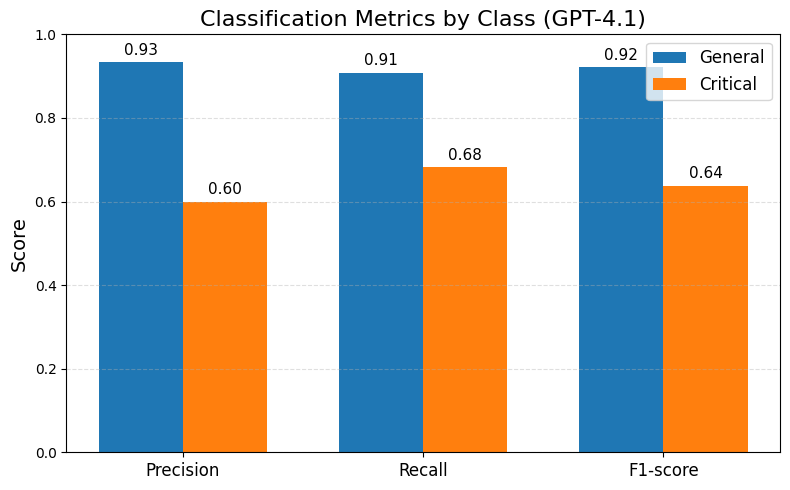

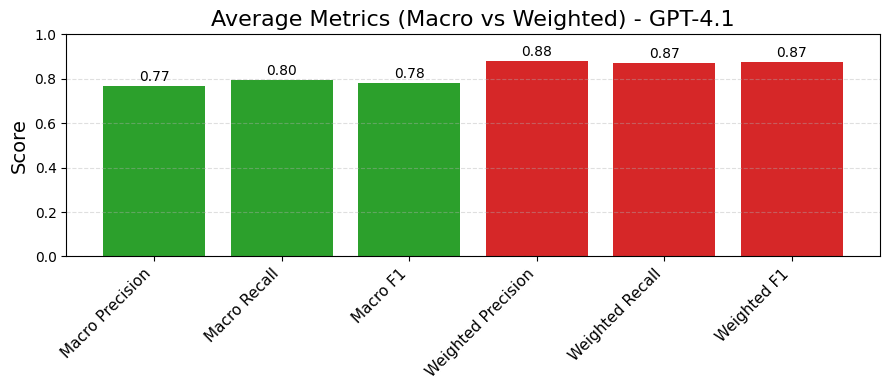

Overall Accuracy: 0.8702


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Classification report (both classes) from the code above
#   General precision=0.9340, recall=0.9083, f1=0.9209
#   Critical precision=0.6000, recall=0.6818, f1=0.6383
#
# Accuracy = 0.8702
# Macro Avg = (precision=0.7670, recall=0.7950, f1=0.7796)
# Weighted Avg = (precision=0.8779, recall=0.8702, f1=0.8735)

classes = ["General", "Critical"]
precision = [0.9340, 0.6000]
recall = [0.9083, 0.6818]
f1_score_cls = [0.9209, 0.6383]

macro_precision = 0.7670
macro_recall = 0.7950
macro_f1 = 0.7796
weighted_precision = 0.8779
weighted_recall = 0.8702
weighted_f1 = 0.8735

metrics = ["Precision", "Recall", "F1-score"]
general_vals = [precision[0], recall[0], f1_score_cls[0]]
critical_vals = [precision[1], recall[1], f1_score_cls[1]]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_gen = ax.bar(x - width/2, general_vals, width, label="General", color="#1f77b4")
bars_crit = ax.bar(x + width/2, critical_vals, width, label="Critical", color="#ff7f0e")

ax.set_ylabel("Score", fontsize=14)
ax.set_title("Classification Metrics by Class (GPT-4.1)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=12)

def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

annotate_bars(bars_gen)
annotate_bars(bars_crit)

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

avg_labels = ["Macro Precision", "Macro Recall", "Macro F1",
              "Weighted Precision", "Weighted Recall", "Weighted F1"]
avg_scores = [macro_precision, macro_recall, macro_f1,
              weighted_precision, weighted_recall, weighted_f1]
avg_colors = ["#2ca02c", "#2ca02c", "#2ca02c", "#d62728", "#d62728", "#d62728"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(avg_labels, avg_scores, color=avg_colors)

ax.set_ylabel("Score", fontsize=14)
ax.set_title("Average Metrics (Macro vs Weighted) - GPT-4.1", fontsize=16)
ax.set_ylim(0, 1.0)
plt.xticks(rotation=45, ha="right", fontsize=11)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.01,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

accuracy = 0.8702
print(f"Overall Accuracy: {accuracy:.4f}")

Now we can see that because there was not enough representation of all the classes, the classification model did not perform well enough in relation to the baseline codes and models, so we will create a new Azure data model and classify it using the GPT 4.1 model.

40% Critical Augmentation + RAG+GPT-4.1 Classification
1. Load the original labeled DataFrame (543 General, 112 Critical).
2. Compute how many synthetic Critical questions are needed to reach ~40% Critical.
3. Generate that many synthetic Critical questions via Azure OpenAI GPT-4.1.
4. Combine the originals and synthetics into an augmented DataFrame.
5. Perform a stratified 80/20 train/test split.
6. Build a compact few- shot prompt from the training set (2 examples per class).
7. Classify each test question using RAG retrieval + GPT-4.1 prompting.
8. Compute and display evaluation metrics (per- class, macro avg, weighted avg).


In [ ]:
import os
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from openai import AzureOpenAI

In [ ]:
api_key = "SECRET"
endpoint = "SECRET"
api_version = "2025-01-01-preview"
model_deploy = "gpt-4.1"

client = AzureOpenAI(
    api_key=api_key,
    azure_endpoint=endpoint,
    api_version=api_version
)

In [ ]:
# Load Original Labeled DataFrame
original_df = pd.read_excel("/content/MedInfo2019-QA-MedicationsFINAL (1) (4).xlsx")

# Print column names
print("Columns in the Excel file:", original_df.columns.tolist())

# Drop rows missing "Question" or "Risk_Level"
original_df = original_df.dropna(subset=["Question", "Risk_Level"])

# Create a new "label" column by normalizing "Risk_Level"
original_df["label"] = original_df["Risk_Level"].astype(str).str.strip().str.capitalize()

# Ensure labels are only "General" or "Critical"
assert set(original_df["label"].unique()) <= {"General", "Critical"}, \
       "Risk_Level must contain only 'General' or 'Critical'."

# Count how many examples in each class originally
n_general_orig  = original_df[original_df["label"] == "General"].shape[0]   # expected ~543
n_critical_orig = original_df[original_df["label"] == "Critical"].shape[0]  # expected ~112

# Compute how many synthetic Critical questions are needed to reach ~40% Critical
# Solve: (C0 + n) / (G + C0 + n) = 0.4  =>  n = ((0.4 * G) - (0.6 * C0)) / 0.6
needed_crit_synth = int((0.4 * n_general_orig - 0.6 * n_critical_orig) / 0.6)
if needed_crit_synth < 0:
    needed_crit_synth = 0

print(f"Original counts -> General: {n_general_orig}, Critical: {n_critical_orig}")
print(f"Will generate {needed_crit_synth} synthetic Critical questions to reach ~40% representation.")

# Function to Generate One Synthetic Critical Question
def generate_one_synthetic_critical(source_question: str) -> str:
    """
    Calls GPT-4.1 to produce exactly one new Critical question
    based on the given source critical question.
    """
    prompt = f"""
You are a medical expert specializing in pharmacology and drug–drug interaction safety.
Generate 1 new, unique medical question about a drug interaction that should be classified as "Critical"
(i.e., a combination with potential life-threatening adverse effects), based on this example:
"{source_question}"

– Use only real, commonly prescribed drug names.
– Ensure the question involves two or more drugs known or plausibly capable of dangerous interactions.
– Vary the therapeutic classes (e.g., anticoagulants, antibiotics, antiarrhythmics, antidepressants, statins).
– Do not invent fictitious drug names or unusual indications.
– Format the question as a single line, without numbering or quotes.

Example:
Does combining warfarin with aspirin increase bleeding risk?

Now generate exactly 1 such Critical question:
""".strip()

    response = client.chat.completions.create(
        model            = model_deploy,
        messages         = [
            {"role": "system", "content": "You are a medical expert proficient in drug–drug interaction safety."},
            {"role": "user",   "content": prompt}
        ],
        temperature      = 0.0,
        max_tokens       = 200,
        presence_penalty = 0.0
    )
    text = response.choices[0].message.content.strip()
    new_q = text.split("\n")[0].strip()
    return new_q

# Generate Synthetic Critical Questions in Batch
critical_originals = original_df[original_df["label"] == "Critical"]["Question"].tolist()
synthetic_critical = []
seen_set = set(original_df["Question"].str.lower())

attempts = 0
max_attempts = needed_crit_synth * 5  # safety cap to avoid infinite loop

print("Generating synthetic Critical questions (batch)...")
while len(synthetic_critical) < needed_crit_synth and attempts < max_attempts:
    attempts += 1
    source_q = random.choice(critical_originals)
    try:
        new_q = generate_one_synthetic_critical(source_q)
    except Exception as e:
        print(f"Error calling GPT for source '{source_q}': {e}")
        continue

    norm = new_q.lower()
    if norm not in seen_set:
        synthetic_critical.append(new_q)
        seen_set.add(norm)

print(f"Actually generated {len(synthetic_critical)} unique synthetic Critical questions after {attempts} attempts.")

# Build Augmented DataFrame:
# Create DataFrame for synthetic Critical
df_synth_crit = pd.DataFrame({
    "Question": synthetic_critical,
    "label":    ["Critical"] * len(synthetic_critical)
})

# Keep all General /Critical originals; do not modify originals
augmented_df = pd.concat([original_df[["Question","label"]], df_synth_crit], ignore_index=True)
augmented_df = augmented_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("\nBalanced augmented_df label distribution:")
print(augmented_df["label"].value_counts())
# Expected output:
# General     543
# Critical    362

# Stratified 80/20 Train/Test Split
train_df, test_df_full = train_test_split(
    augmented_df,
    test_size    = 0.20,
    stratify     = augmented_df["label"],
    random_state = 42
)

# If not shrinking, use full 20%:
test_df = test_df_full.copy()

print("\nFinal Train distribution:")
print(train_df["label"].value_counts())
print("Final Test distribution:")
print(test_df["label"].value_counts())
# Roughly: Train ≈ (434 General, 290 Critical), Test ≈ (109 General, 72 Critical)

# Build Few‐Shot Examples from the Training Set
def build_few_shot_text(train_df: pd.DataFrame, n_examples_per_class: int = 2, seed: int = 42) -> str:
    """
    Randomly sample 'n_examples_per_class' from each label in train_df.
    Returns a formatted few-shot string:
      1) Question: "..." -> "Critical"
      2) Question: "..." -> "General"
      ...
    """
    random.seed(seed)
    few_shot_lines = []

    for label in ["Critical", "General"]:
        subset = train_df[train_df["label"] == label]
        if len(subset) < n_examples_per_class:
            sampled = subset
        else:
            sampled = subset.sample(n=n_examples_per_class, random_state=seed)

        for _, row in sampled.iterrows():
            q_text = row["Question"].strip().replace("\n", " ")
            if len(q_text) > 250:
                q_text = q_text[:250]
            few_shot_lines.append(f'Question: "{q_text}" -> "{label}"')

    few_shot_text = ""
    for i, line in enumerate(few_shot_lines, start=1):
        few_shot_text += f"{i}) {line}\n"

    return few_shot_text.strip()

few_shot_text = build_few_shot_text(train_df, n_examples_per_class=2, seed=42)
print("\n--- FEW‐SHOT EXAMPLES (after balanced augmentation) ---")
print(few_shot_text)

# Classification Function (RAG + GPT-4.1)
def classify_question_with_rag_balanced(question: str, few_shot_examples: str, top_k: int = 3) -> str:
    """
    1) Retrieve top_k relevant passages from the RAG corpus for 'question'.
    2) Build a prompt including instructions, fixed examples, few‐shot, and retrieved context.
    3) Send to Azure OpenAI GPT-4.1 for classification.
    4) Return "General" or "Critical".
    """
    # Retrieve top_k passages via RAG
    retrieved_chunks = retrieve_topk(question, k=top_k)
    context_text = "\n----\n".join(retrieved_chunks)

    # Construct prompt
    prompt = f"""
Instructions:
You are a medical classification assistant with expertise in evaluating drug–drug interactions, adverse effects, and clinical safety.
Always prioritize identifying potential life-threatening interactions, even if they are rare.
Given a question about drug interactions or medical usage, classify it as "General" (no immediate risk) or "Critical" (potentially dangerous interaction).
Always use the “Relevant context” passages provided below to inform your classification decision.
Do not provide explanations—answer only with the single word "General" or "Critical".

Examples:
1) Question: "Does taking warfarin with aspirin increase bleeding risk?" -> "Critical"
2) Question: "What is the standard adult dose of amoxicillin for a mild ear infection?" -> "General"
3) Question: "Is it safe to combine lamotrigine (for epilepsy) with valproate?" -> "Critical"
4) Question: "How much ibuprofen can I take daily for mild pain relief?" -> "General"
5) Question: "Can metformin be taken together with sitagliptin, and what are the risks?" -> "Critical"

Few-shot examples:
{few_shot_examples}

Relevant context (top-{top_k} passages):
{context_text}

Test question:
"{question}"

Answer:
""".strip()

    # Call GPT-4.1
    response = client.chat.completions.create(
        model = model_deploy,
        messages = [
            {
                "role": "system",
                "content": (
                    "You are a highly knowledgeable and cautious medical expert. "
                    "When classifying questions about drug–drug interactions or medical usage, "
                    "always err on the side of identifying potential life-threatening interactions. "
                    "If you are even slightly uncertain whether an interaction could be dangerous, "
                    "classify the question as “Critical.”"
                )
            },
            {"role": "user", "content": prompt}
        ],
        temperature = 0.0,
        max_tokens = 6,    # only need one word: "General" or "Critical"
        presence_penalty = 0.0
    )

    # Extract and normalize the model’s reply
    prediction = response.choices[0].message.content.strip()
    lower = prediction.lower()
    if lower.startswith("general"):
        return "General"
    elif lower.startswith("critical"):
        return "Critical"
    else:
        return "General"

# Run Classification on the Test Set & Compute Metrics
y_true = []
y_pred = []

print("\nRunning classification on the test set...")
for idx, row in test_df.iterrows():
    q_text   = row["Question"].strip()
    true_lbl = row["label"]
    pred_lbl = classify_question_with_rag_balanced(q_text, few_shot_text, top_k=3)
    y_true.append(true_lbl)
    y_pred.append(pred_lbl)
    print(f"  [Finished idx={idx}] True: {true_lbl}  Pred: {pred_lbl}")

# Convert to numeric IDs (General=0, Critical=1)
label_to_id = {"General": 0, "Critical": 1}
y_true_ids = [label_to_id[l] for l in y_true]
y_pred_ids = [label_to_id[l] for l in y_pred]

# Compute performance metrics for Critical only
accuracy = accuracy_score(y_true_ids, y_pred_ids)
precision = precision_score(y_true_ids, y_pred_ids, pos_label=1)
recall = recall_score(y_true_ids, y_pred_ids, pos_label=1)
f1 = f1_score(y_true_ids, y_pred_ids, pos_label=1)
conf_mat = confusion_matrix(y_true_ids, y_pred_ids)

print("\n===== EVALUATION RESULTS (Critical-only) =====")
print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision (Critical) : {precision:.4f}")
print(f"Recall    (Critical) : {recall:.4f}")
print(f"F1-score  (Critical) : {f1:.4f}")
print("Confusion Matrix (rows=true, cols=predicted):")
print(conf_mat)

# Display full classification report for both classes
print("\n===== CLASSIFICATION REPORT (both classes) =====")
print(classification_report(
    y_true_ids,
    y_pred_ids,
    target_names=["General", "Critical"],
    digits=4
))

# Extract macro & weighted averages for reporting
rep_dict = classification_report(
    y_true_ids,
    y_pred_ids,
    target_names=["General", "Critical"],
    output_dict=True
)
macro_precision = rep_dict["macro avg"]["precision"]
macro_recall = rep_dict["macro avg"]["recall"]
macro_f1 = rep_dict["macro avg"]["f1-score"]
weighted_precision = rep_dict["weighted avg"]["precision"]
weighted_recall = rep_dict["weighted avg"]["recall"]
weighted_f1 = rep_dict["weighted avg"]["f1-score"]

print("\n===== AVERAGE METRICS =====")
print(f"Macro Avg — Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1: {macro_f1:.4f}")
print(f"Weighted Avg — Precision: {weighted_precision:.4f}, Recall: {weighted_recall:.4f}, F1: {weighted_f1:.4f}")

Columns in the Excel file: ['Question', 'Risk_Level', 'Focus (Drug)', 'Question Type', 'Answer', 'Section Title', 'URL']
Original counts -> General: 543, Critical: 112
Will generate 250 synthetic Critical questions to reach ~40% representation.
Generating synthetic Critical questions (batch)...
Actually generated 90 unique synthetic Critical questions after 1250 attempts.

Balanced augmented_df label distribution:
label
General     543
Critical    202
Name: count, dtype: int64

Final Train distribution:
label
General     434
Critical    162
Name: count, dtype: int64
Final Test distribution:
label
General     109
Critical     40
Name: count, dtype: int64

--- FEW‐SHOT EXAMPLES (after balanced augmentation) ---
1) Question: "Is it safe to take amiodarone and simvastatin together due to risk of severe muscle breakdown?" -> "Critical"
2) Question: "Can taking simvastatin together with clarithromycin cause life-threatening muscle breakdown?" -> "Critical"
3) Question: "what is the imprint o

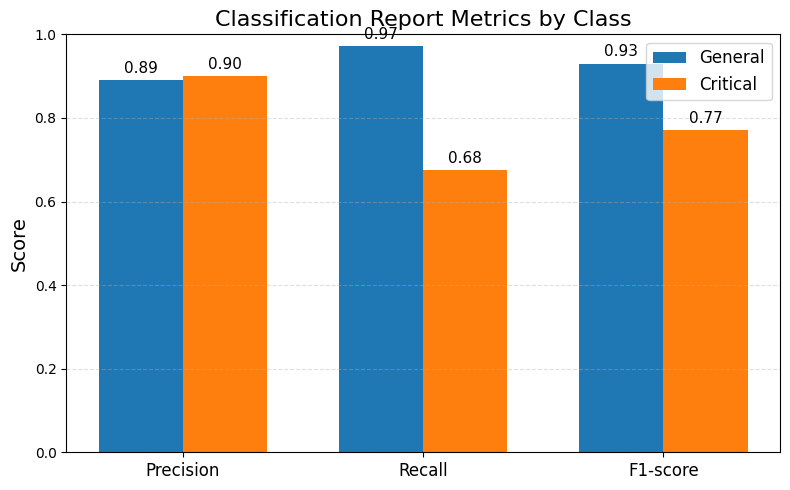

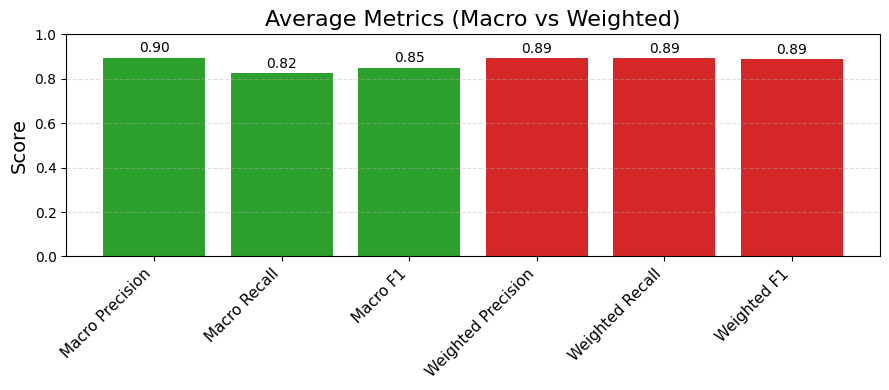

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# from previous results:
classes = ["General", "Critical"]
precision = [0.8908, 0.9000]
recall    = [0.9725, 0.6750]
f1_score  = [0.9298, 0.7714]

metrics = ["Precision", "Recall", "F1-score"]
general_vals  = [precision[0], recall[0], f1_score[0]]
critical_vals = [precision[1], recall[1], f1_score[1]]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_general = ax.bar(x - width/2, general_vals, width, label="General", color="#1f77b4")
bars_critical = ax.bar(x + width/2, critical_vals, width, label="Critical", color="#ff7f0e")

ax.set_ylabel("Score", fontsize=14)
ax.set_title("Classification Report Metrics by Class", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=12)

def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

annotate_bars(bars_general)
annotate_bars(bars_critical)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

macro_precision = 0.8954
macro_recall = 0.8237
macro_f1 = 0.8506
weighted_precision = 0.8932
weighted_recall = 0.8926
weighted_f1 = 0.8873

avg_metrics = ["Macro Precision", "Macro Recall", "Macro F1",
               "Weighted Precision", "Weighted Recall", "Weighted F1"]
avg_scores = [macro_precision, macro_recall, macro_f1,
              weighted_precision, weighted_recall, weighted_f1]
colors = ["#2ca02c", "#2ca02c", "#2ca02c", "#d62728", "#d62728", "#d62728"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(avg_metrics, avg_scores, color=colors)

ax.set_ylabel("Score", fontsize=14)
ax.set_title("Average Metrics (Macro vs Weighted)", fontsize=16)
ax.set_ylim(0, 1.0)
plt.xticks(rotation=45, ha="right", fontsize=11)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

10 examples for generated questions:

In [ ]:
import random
import pandas as pd

num_to_display = min(10, len(synthetic_critical))
random_subset = random.sample(synthetic_critical, num_to_display)

print(f"Displaying {num_to_display} random synthetic Critical questions:\n")
for idx, q in enumerate(random_subset, start=1):
    print(f"{idx}. {q}")

df_random10 = pd.DataFrame({
    "Synthetic_Critical_Question": random_subset
})
print("\nAs DataFrame:")
print(df_random10)

Displaying 10 random synthetic Critical questions:

1. Is it safe to take fluoxetine with linezolid due to the risk of serotonin syndrome?
2. Is it dangerous to take amiodarone and simvastatin together?
3. Is it dangerous to take amiodarone and simvastatin together due to risk of severe muscle breakdown?
4. Is it dangerous to prescribe amiodarone together with simvastatin due to risk of severe muscle toxicity?
5. What are the dangers of taking fluconazole together with simvastatin?
6. Is it safe to prescribe clarithromycin with simvastatin due to risk of severe muscle toxicity?
7. Can coadministration of amiodarone and simvastatin increase the risk of severe muscle toxicity?
8. What are the dangers of co-administering amiodarone and simvastatin in patients with cardiac arrhythmias?
9. Is it dangerous to co-administer simvastatin and clarithromycin due to risk of severe rhabdomyolysis?
10. Is it safe to co-administer amiodarone with simvastatin due to risk of severe myopathy or rhabdomy